In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

Zadanie 1. Segmentacja obrazu za pomocą algorytmu k-średnich.
1.1. Wyświetlenie kodów RGB dla każdego piksela.
1.2. Wyświetlenie oryginalnego zdjęcia.

Kody RGB dla każdego piksela:
[[[ 28  35  63]
  [ 35  50  83]
  [ 98 118 153]
  ...
  [  3   3   3]
  [  3   3   3]
  [  3   3   3]]

 [[ 25  29  56]
  [ 36  47  79]
  [ 98 117 150]
  ...
  [  3   3   3]
  [  3   3   3]
  [  4   4   4]]

 [[ 25  23  47]
  [ 36  43  72]
  [ 98 113 146]
  ...
  [  3   3   3]
  [  4   4   4]
  [  4   4   4]]

 ...

 [[ 46  32  31]
  [ 44  30  29]
  [ 49  34  31]
  ...
  [ 35  25  23]
  [ 36  26  24]
  [ 36  26  24]]

 [[ 36  20  20]
  [ 47  31  31]
  [ 59  41  39]
  ...
  [ 42  32  30]
  [ 39  29  27]
  [ 37  27  25]]

 [[ 41  27  26]
  [ 49  33  33]
  [ 58  40  38]
  ...
  [ 59  43  43]
  [ 51  37  36]
  [ 46  32  31]]]


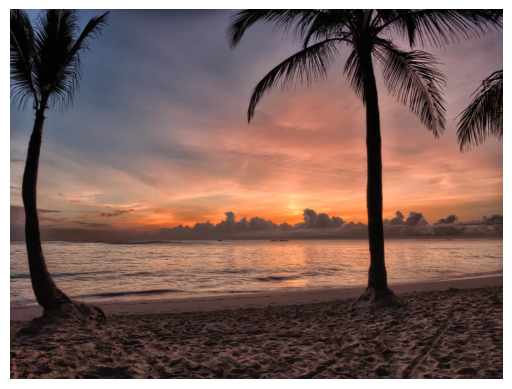

In [3]:

image = Image.open('palm_tree.jpg')
image_rgb = np.array(image)

print("Kody RGB dla każdego piksela:")
print(image_rgb)

plt.imshow(image)
plt.axis('off') 
plt.show()


1.3. Wykonanie kwantyzacji kolorów za pomocą algorytmu k-średnich.
1.4. Wyświetlenie rozmiarów zdjęcia i liczbę kanałów kolorów (RGB).
1.5. Przekształcenie danych z formatu 3D (w, h, c) do 2D (w * h, c).

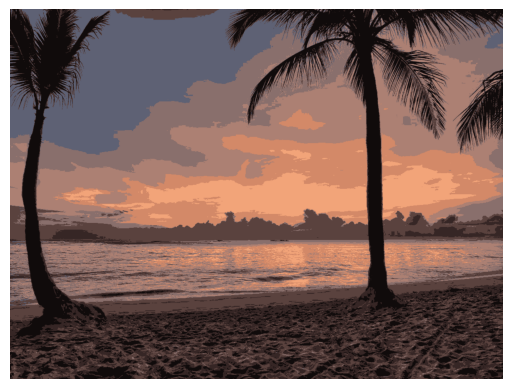

In [4]:
pixels = image_rgb.reshape(-1, 3)  # Z (w, h, c) do (w * h, c)

num_colors = 8
kmeans = KMeans(n_clusters=num_colors, random_state=42)
kmeans.fit(pixels)

quantized_pixels = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8) 
quantized_image = quantized_pixels.reshape(image_rgb.shape)  

plt.imshow(quantized_image)
plt.axis('off')
plt.show()


In [5]:
height, width, channels = image_rgb.shape
print(f"Rozmiar zdjęcia: {width}x{height}")
print(f"Liczba kanałów kolorów: {channels}")

Rozmiar zdjęcia: 1100x825
Liczba kanałów kolorów: 3


In [6]:
pixels_2d = image_rgb.reshape(-1, 3)
print("Wymiary po przekształceniu do 2D:", pixels_2d.shape)

Wymiary po przekształceniu do 2D: (907500, 3)


1.6. Zastosowanie algorytm k-średnich dla 6 klastrów.
1.7. Wyświetlenie etykiet klastrów dla każdego piksela.
1.8. Wyświetlenie współrzędne centroidów.
1.9. Zaokrąglenie współrzędnych centroidów (kolory) do 0 miejsc po przecinku.
1.10. Utworzenie skwantyzowanego obrazu, zamieniając każdy piksel na odpowiadający mu
kolor centroidu.
1.11. Wyświetlenie obrazu po kwantyzacji.

In [7]:
pixels = image_rgb.reshape(-1, 3)  # Z (w, h, c) do (w * h, c)
num_clusters = 6
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(pixels)

# 1.7 
labels = kmeans.labels_
print("Etykiety klastrów dla każdego piksela:")
print(labels.reshape(image_rgb.shape[:2])) 

Etykiety klastrów dla każdego piksela:
[[4 1 2 ... 4 4 4]
 [4 1 2 ... 4 4 4]
 [4 1 2 ... 4 4 4]
 ...
 [4 4 4 ... 4 4 4]
 [4 4 1 ... 4 4 4]
 [4 4 1 ... 1 1 4]]


In [8]:
# 1.8
centroids = kmeans.cluster_centers_
print("Współrzędne centroidów (kolory RGB):")
print(centroids)

# 1.9 
centroids_rounded = np.round(centroids, 0).astype(int)
print("Zaokrąglone współrzędne centroidów (kolory RGB):")
print(centroids_rounded)

Współrzędne centroidów (kolory RGB):
[[144.16113952 115.8572963  112.09586089]
 [ 76.52839599  55.35968422  53.07647424]
 [ 99.65330218  94.73421167 108.62392137]
 [234.204125   154.64958728 114.29867123]
 [ 24.1517086   16.59534821  16.31434705]
 [185.27100511 130.96160228 111.25947998]]
Zaokrąglone współrzędne centroidów (kolory RGB):
[[144 116 112]
 [ 77  55  53]
 [100  95 109]
 [234 155 114]
 [ 24  17  16]
 [185 131 111]]


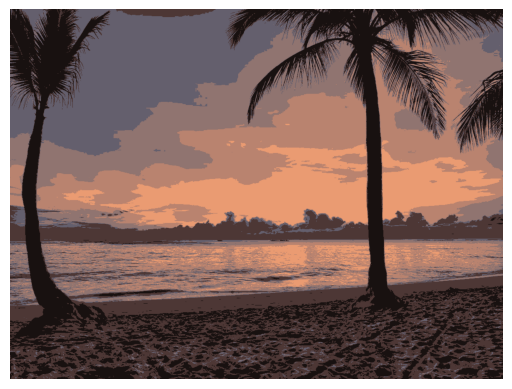

In [9]:
# 1.10 
quantized_pixels = centroids_rounded[labels]  
quantized_image = quantized_pixels.reshape(image_rgb.shape) 

# 1.11 
plt.imshow(quantized_image)
plt.axis('off')
plt.show()

Zadanie 2. Korzystając ze zbioru danych iris.csv, proszę o wykonanie następujących czynności:
2.1. Wczytanie danych.
2.2. Sprawdzenie kompletności danych.
2.3. Sprawdzenie statystyk podstawowych, informacji nt. danych.

In [10]:
iris_df = pd.read_csv('iris.csv')
print(iris_df.head())

print(iris_df.isnull().sum())

print(iris_df.describe())

print(iris_df.info())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000 

2.4. Wykres punktowy zależności długości płatka w funkcji szerokości płatka. Na jaką ilość
skupień można podzielić zbiór danych?
2.5. Wykres punktowy zależności długości płatka w funkcji szerokości płatka, dane
różnicowane za pomocą gatunku/rodzaju.

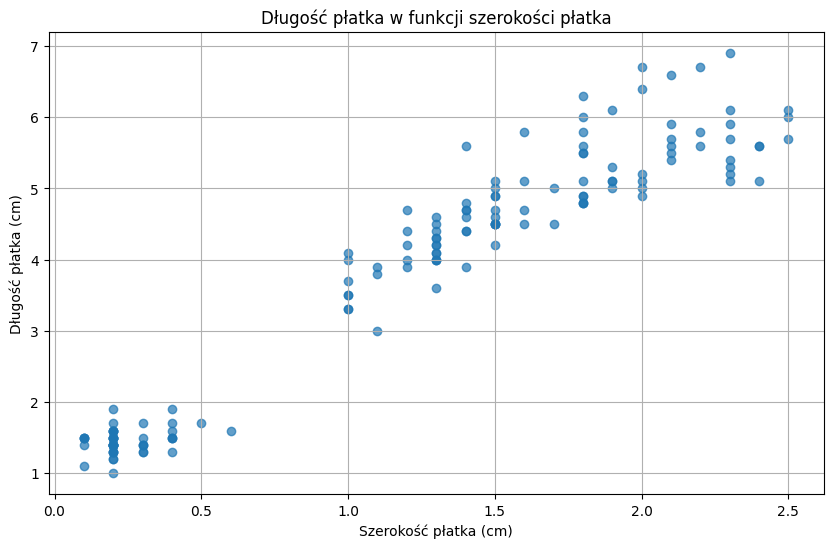

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(iris_df['petal_width'], iris_df['petal_length'], alpha=0.7)
plt.title('Długość płatka w funkcji szerokości płatka')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')
plt.grid()
plt.show()

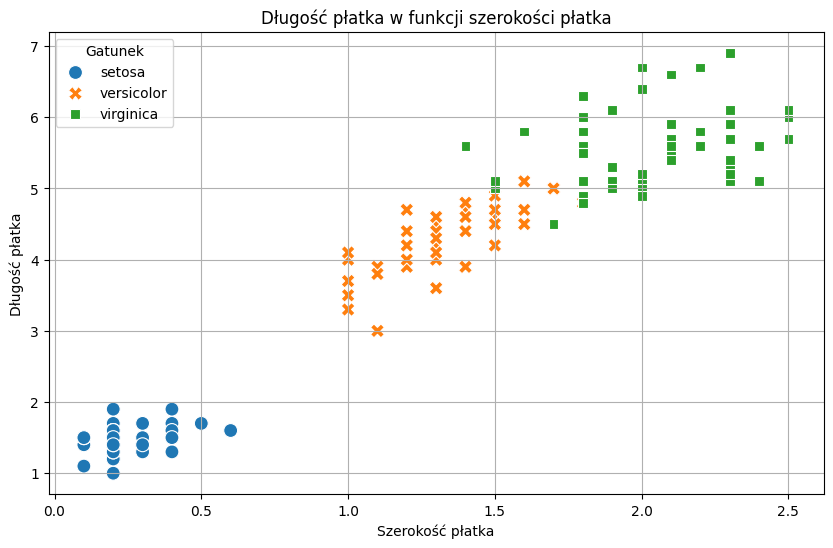

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x='petal_width', y='petal_length', hue='species', style='species', s=100)
plt.title('Długość płatka w funkcji szerokości płatka')
plt.xlabel('Szerokość płatka')
plt.ylabel('Długość płatka')
plt.legend(title='Gatunek')
plt.grid()
plt.show()

2.6. Przygotowanie nowego obiektu df_iris, w której zostanie usunięta kolumna 'species'.
2.7. Przygotowanie nowego obiekt df_iris_std (z punktu 2.6), gdzie dane wejściowe będą
zestandaryzowane.
2.8. Przygotowanie nowego obiekt df_iris_norm (z punktu 2.6), gdzie dane wejściowe będą
znormalizowane w zakresie [0,1].

In [13]:

# 2.6
df_iris = iris_df.drop(columns=['species'])
print("Nowy zbiór danych df_iris bez kolumny 'Species':")
print(df_iris.head())

# 2.7
scaler = StandardScaler()
df_iris_std = pd.DataFrame(scaler.fit_transform(df_iris), columns=df_iris.columns)
print("\nZestandaryzowany zbiór danych df_iris_std:")
print(df_iris_std.head())

# 2.8
scaler_minmax = MinMaxScaler()
df_iris_norm = pd.DataFrame(scaler_minmax.fit_transform(df_iris), columns=df_iris.columns)
print("\nZnormalizowany zbiór danych df_iris_norm:")
print(df_iris_norm.head())

Nowy zbiór danych df_iris bez kolumny 'Species':
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Zestandaryzowany zbiór danych df_iris_std:
   sepal_length  sepal_width  petal_length  petal_width
0     -0.900681     1.032057     -1.341272    -1.312977
1     -1.143017    -0.124958     -1.341272    -1.312977
2     -1.385353     0.337848     -1.398138    -1.312977
3     -1.506521     0.106445     -1.284407    -1.312977
4     -1.021849     1.263460     -1.341272    -1.312977

Znormalizowany zbiór danych df_iris_norm:
   sepal_length  sepal_width  petal_length  petal_width
0      0.222222     0.625000      0.067797     0.041667
1      0.166667     0.416667      0.067797     0.041667
2      0.111111     0.50

2.9. Przygotowanie 3 heatmap. Jakich informacji nt. zbioru danych dotyczących irysów
dostarczają mapy korelacji:
a. dane wejściowe (punkt 2.6),
b. dane zestandaryzowane (punkt 2.7),
c. dane znormalizowane (punkt 2.8).

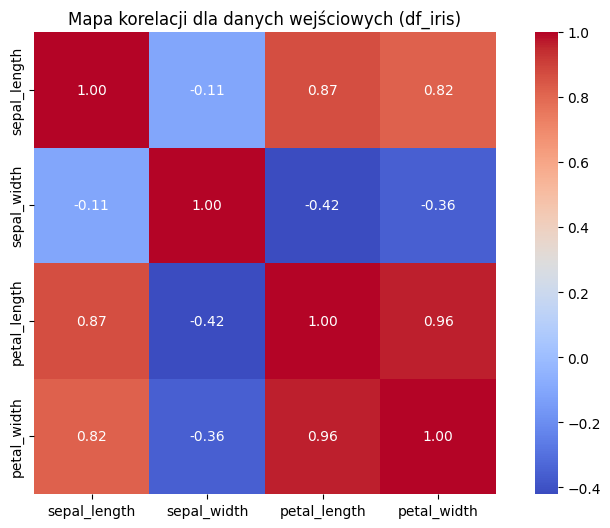

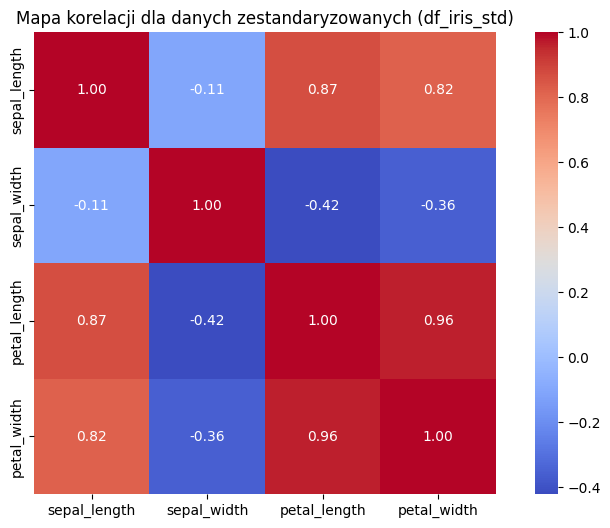

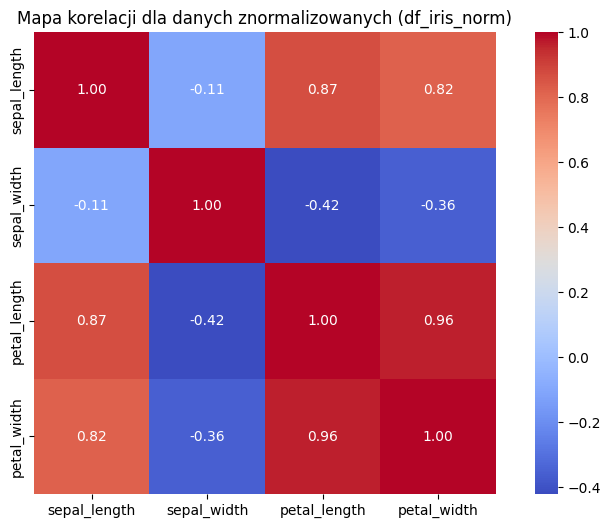

In [14]:
# a. Mapa korelacji dla danych wejściowych
plt.figure(figsize=(10, 6))
sns.heatmap(df_iris.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Mapa korelacji dla danych wejściowych (df_iris)')
plt.show()

# b. Mapa korelacji dla danych zestandaryzowanych
plt.figure(figsize=(10, 6))
sns.heatmap(df_iris_std.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Mapa korelacji dla danych zestandaryzowanych (df_iris_std)')
plt.show()

# c. Mapa korelacji dla danych znormalizowanych
plt.figure(figsize=(10, 6))
sns.heatmap(df_iris_norm.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Mapa korelacji dla danych znormalizowanych (df_iris_norm)')
plt.show()


2.10. Dla danych oryginalnych:
2.10.1. Zastosować algorytm hierarchiczny metody aglomeracyjnej dla odpowiedniej liczby
grup (patrz: 2.4., 2.5.), dla 3 metod łączenia:
a. Warda,
b. pojedynczego połączenia,
c. całkowitego połączenia.
2.10.2. Zastosowanie algorytmu k-średnich dla odpowiedniej liczby grup (patrz: 2.4., 2.5.).

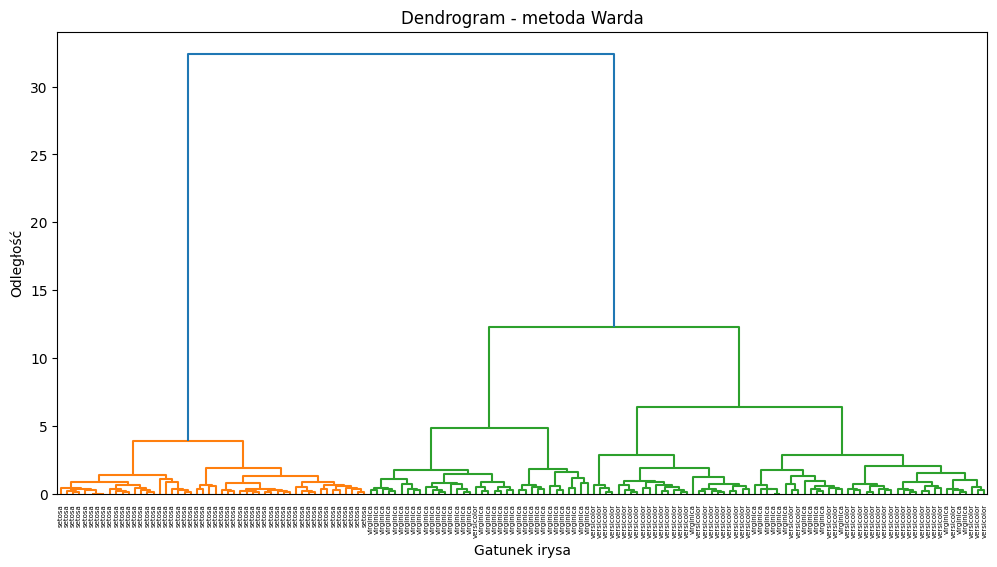

In [15]:
# 2.10.1.a - Algorytm hierarchiczny - metoda Warda
plt.figure(figsize=(12, 6))
linked = linkage(iris_df.drop(columns=['species']), method='ward')
dendrogram(linked, orientation='top', labels=iris_df['species'].values)
plt.title('Dendrogram - metoda Warda')
plt.xlabel('Gatunek irysa')
plt.ylabel('Odległość')
plt.show()

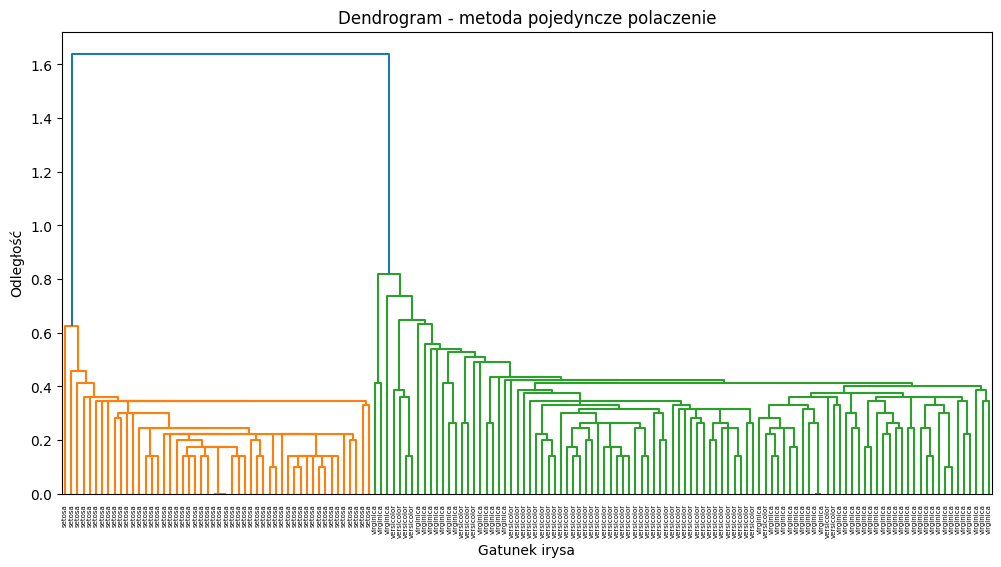

In [16]:
# 2.10.1.b - Algorytm hierarchiczny - pojedyncze połączenie
plt.figure(figsize=(12, 6))
linked = linkage(iris_df.drop(columns=['species']), method='single')
dendrogram(linked, orientation='top', labels=iris_df['species'].values)
plt.title('Dendrogram - metoda pojedyncze polaczenie')
plt.xlabel('Gatunek irysa')
plt.ylabel('Odległość')
plt.show()

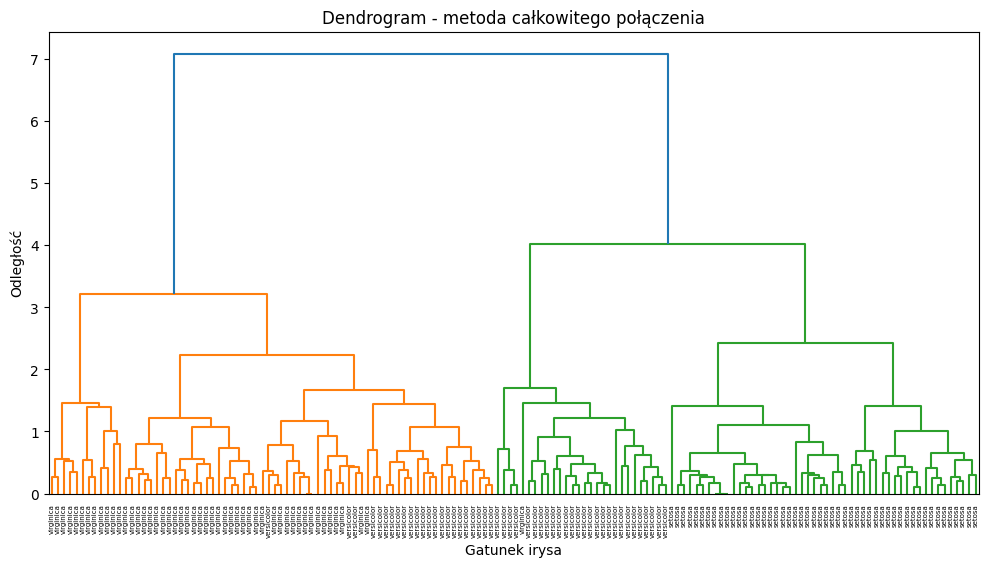

In [17]:
# 2.10.1.c - Algorytm hierarchiczny - metoda calkowitego polaczenia
plt.figure(figsize=(12, 6))
linked = linkage(iris_df.drop(columns=['species']), method='complete')
dendrogram(linked, orientation='top', labels=iris_df['species'].values)
plt.title('Dendrogram - metoda całkowitego połączenia')
plt.xlabel('Gatunek irysa')
plt.ylabel('Odległość')
plt.show()

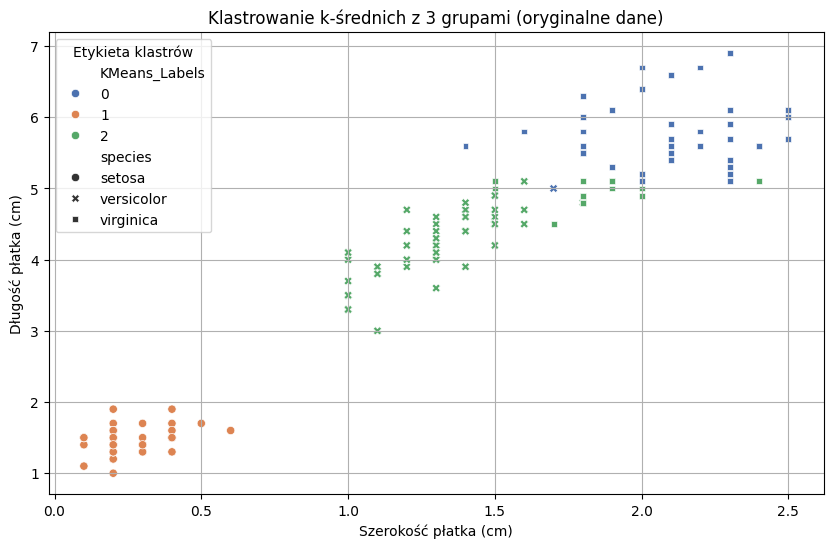

In [18]:
# 2.10.2 - Algorytm k-średnich dla 3 grup
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(iris_df.drop(columns=['species']))

iris_df['KMeans_Labels'] = kmeans.labels_

plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x='petal_width', y='petal_length', hue='KMeans_Labels', style='species', palette='deep')
plt.title('Klastrowanie k-średnich z 3 grupami (oryginalne dane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')
plt.legend(title='Etykieta klastrów')
plt.grid()
plt.show()

2.10.3. Jaki jest wynik profilu dla poszczególnych rozwiązań uzyskanych metodą aglomeracyjną, a jaki jest wynik profilu dla rozwiązań metodą k-średnich?

In [19]:
n_clusters = 3
agglom = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
iris_df['Agglomerative_Labels'] = agglom.fit_predict(iris_df.drop(columns=['species']))

# Klastrowanie k-średnich
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
iris_df['KMeans_Labels'] = kmeans.fit_predict(iris_df.drop(columns=['species']))

# Wynik profilu dla metody aglomeracyjnej
agglo_profile = iris_df.groupby('Agglomerative_Labels').mean(numeric_only=True)
print("Profil dla klastrów aglomeracyjnych:")
print(agglo_profile)

# Wynik profilu dla metody k-średnich
kmeans_profile = iris_df.groupby('KMeans_Labels').mean(numeric_only=True)
print("\nProfil dla klastrów k-średnich:")
print(kmeans_profile)


Profil dla klastrów aglomeracyjnych:
                      sepal_length  sepal_width  petal_length  petal_width   
Agglomerative_Labels                                                         
0                         5.883607     2.740984      4.388525     1.434426  \
1                         5.006000     3.418000      1.464000     0.244000   
2                         6.853846     3.076923      5.715385     2.053846   

                      KMeans_Labels  
Agglomerative_Labels                 
0                               0.0  
1                               1.0  
2                               2.0  

Profil dla klastrów k-średnich:
               sepal_length  sepal_width  petal_length  petal_width   
KMeans_Labels                                                         
0                  5.883607     2.740984      4.388525     1.434426  \
1                  5.006000     3.418000      1.464000     0.244000   
2                  6.853846     3.076923      5.715385     2.0538

2.10.4. Wykres punktowy zależności długości płatka w funkcji szerokości płatka:
- dane różnicowane za pomocą etykiet nadanych za pomocą algorytmu hierarchicznego
dla każdej metody łączenia.
- dane różnicowane za pomocą etykiet nadanych za pomocą algorytmu k-średnich.

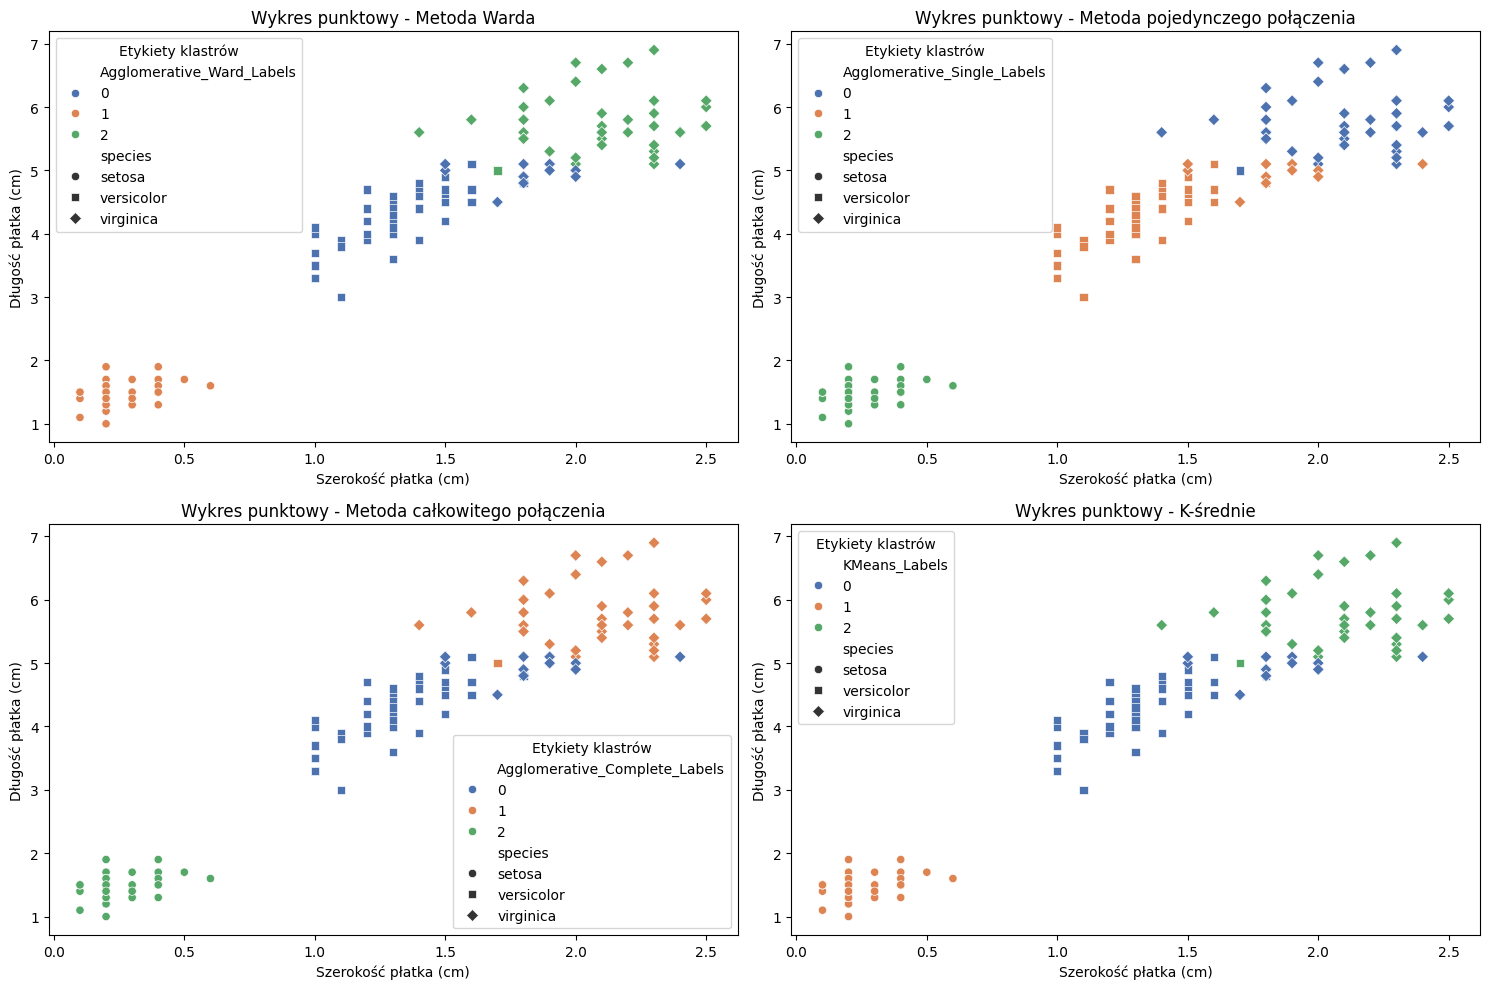

In [20]:
# Klastrowanie aglomeracyjne - metoda Warda
agglom_ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
iris_df['Agglomerative_Ward_Labels'] = agglom_ward.fit_predict(iris_df.drop(columns=['species']))

# Klastrowanie aglomeracyjne - metoda pojedynczego połączenia
agglom_single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
iris_df['Agglomerative_Single_Labels'] = agglom_single.fit_predict(iris_df.drop(columns=['species']))

# Klastrowanie aglomeracyjne - metoda całkowitego połączenia
agglom_complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
iris_df['Agglomerative_Complete_Labels'] = agglom_complete.fit_predict(iris_df.drop(columns=['species']))

# Klastrowanie k-średnich
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
iris_df['KMeans_Labels'] = kmeans.fit_predict(iris_df.drop(columns=['species']))

# Wykresy punktowe
plt.figure(figsize=(15, 10))

# Wykres dla metody Warda
plt.subplot(2, 2, 1)
sns.scatterplot(data=iris_df, x='petal_width', y='petal_length', hue='Agglomerative_Ward_Labels', palette='deep', style='species', markers=['o', 's', 'D'])
plt.title('Wykres punktowy - Metoda Warda')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')
plt.legend(title='Etykiety klastrów')

# Wykres dla metody pojedynczego połączenia
plt.subplot(2, 2, 2)
sns.scatterplot(data=iris_df, x='petal_width', y='petal_length', hue='Agglomerative_Single_Labels', palette='deep', style='species', markers=['o', 's', 'D'])
plt.title('Wykres punktowy - Metoda pojedynczego połączenia')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')
plt.legend(title='Etykiety klastrów')

# Wykres dla metody całkowitego połączenia
plt.subplot(2, 2, 3)
sns.scatterplot(data=iris_df, x='petal_width', y='petal_length', hue='Agglomerative_Complete_Labels', palette='deep', style='species', markers=['o', 's', 'D'])
plt.title('Wykres punktowy - Metoda całkowitego połączenia')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')
plt.legend(title='Etykiety klastrów')

# Wykres dla k-średnich
plt.subplot(2, 2, 4)
sns.scatterplot(data=iris_df, x='petal_width', y='petal_length', hue='KMeans_Labels', palette='deep', style='species', markers=['o', 's', 'D'])
plt.title('Wykres punktowy - K-średnie')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')
plt.legend(title='Etykiety klastrów')

plt.tight_layout()
plt.show()


2.11. Dla danych zestandaryzowanych przeprowadzić klasteryzację jak w 2.10.1-2.10.5.

In [21]:
scaler = StandardScaler()
df_iris_std = pd.DataFrame(scaler.fit_transform(df_iris), columns=df_iris.columns)
print("\nZestandaryzowany zbiór danych df_iris_std:")
print(df_iris_std.head())

# 2.8
scaler_minmax = MinMaxScaler()
df_iris_norm = pd.DataFrame(scaler_minmax.fit_transform(df_iris), columns=df_iris.columns)
print("\nZnormalizowany zbiór danych df_iris_norm:")
print(df_iris_norm.head())


Zestandaryzowany zbiór danych df_iris_std:
   sepal_length  sepal_width  petal_length  petal_width
0     -0.900681     1.032057     -1.341272    -1.312977
1     -1.143017    -0.124958     -1.341272    -1.312977
2     -1.385353     0.337848     -1.398138    -1.312977
3     -1.506521     0.106445     -1.284407    -1.312977
4     -1.021849     1.263460     -1.341272    -1.312977

Znormalizowany zbiór danych df_iris_norm:
   sepal_length  sepal_width  petal_length  petal_width
0      0.222222     0.625000      0.067797     0.041667
1      0.166667     0.416667      0.067797     0.041667
2      0.111111     0.500000      0.050847     0.041667
3      0.083333     0.458333      0.084746     0.041667
4      0.194444     0.666667      0.067797     0.041667


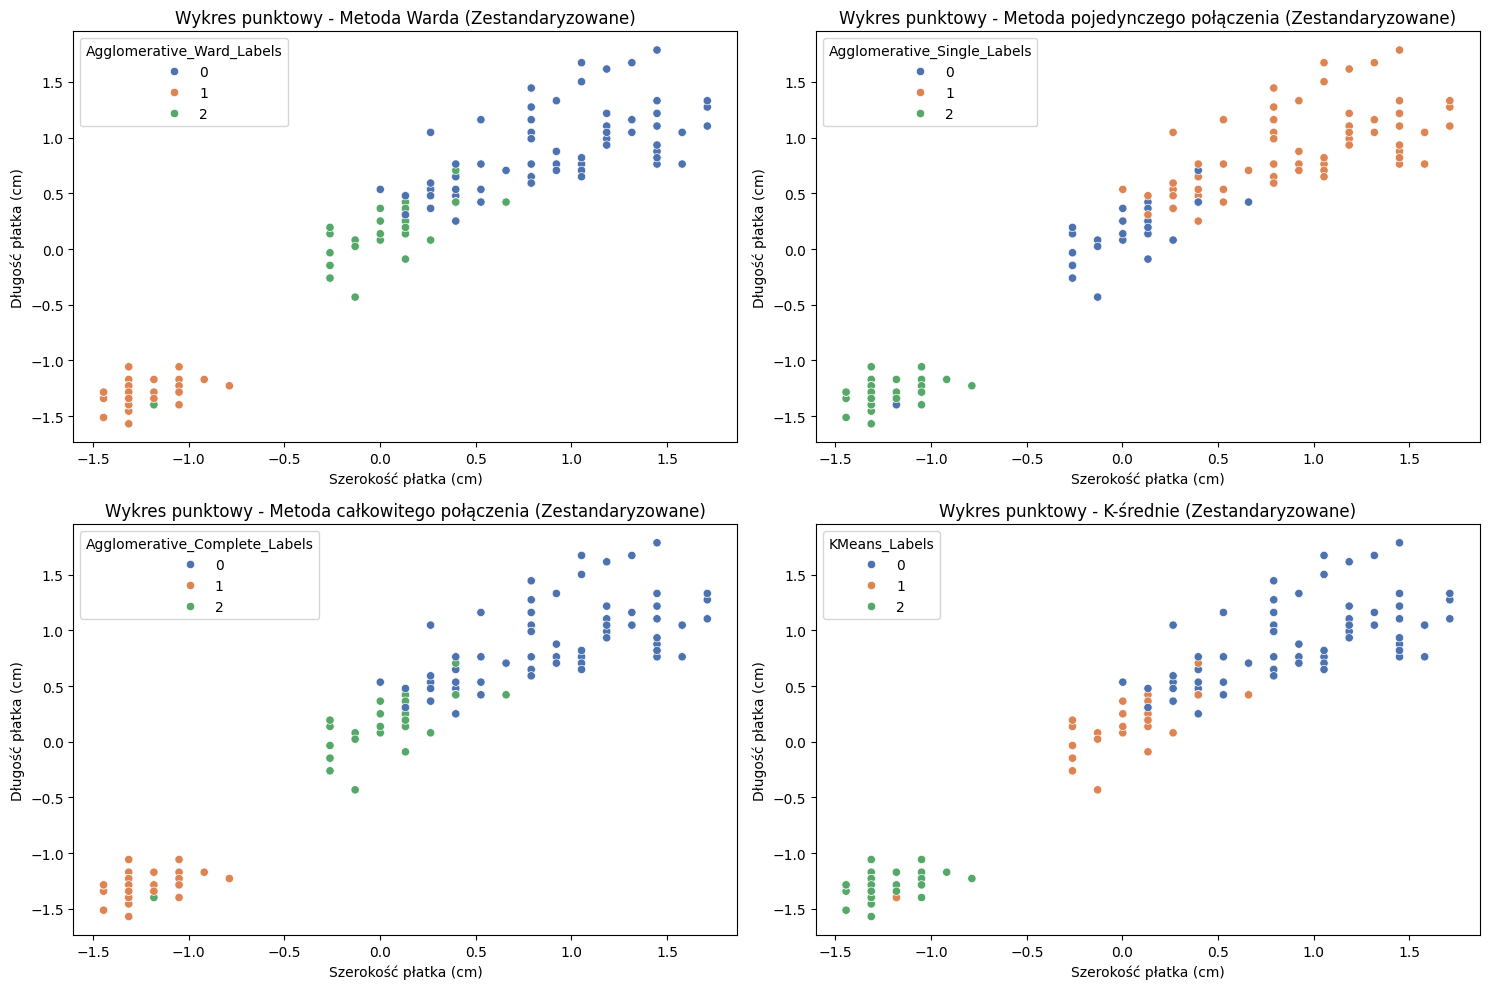

In [22]:
n_clusters = 3

# Klastrowanie aglomeracyjne - metoda Warda
agglom_ward_std = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df_iris_std['Agglomerative_Ward_Labels'] = agglom_ward_std.fit_predict(df_iris_std)

# Klastrowanie aglomeracyjne - metoda pojedynczego połączenia
agglom_single_std = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
df_iris_std['Agglomerative_Single_Labels'] = agglom_single_std.fit_predict(df_iris_std)

# Klastrowanie aglomeracyjne - metoda całkowitego połączenia
agglom_complete_std = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
df_iris_std['Agglomerative_Complete_Labels'] = agglom_complete_std.fit_predict(df_iris_std)

# Klastrowanie k-średnich
kmeans_std = KMeans(n_clusters=n_clusters, random_state=42)
df_iris_std['KMeans_Labels'] = kmeans_std.fit_predict(df_iris_std)

# Wykresy punktowe dla danych zestandaryzowanych
plt.figure(figsize=(15, 10))

# Wykres dla metody Warda
plt.subplot(2, 2, 1)
sns.scatterplot(data=df_iris_std, x='petal_width', y='petal_length', hue='Agglomerative_Ward_Labels', palette='deep')
plt.title('Wykres punktowy - Metoda Warda (Zestandaryzowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

# Wykres dla metody pojedynczego połączenia
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_iris_std, x='petal_width', y='petal_length', hue='Agglomerative_Single_Labels', palette='deep')
plt.title('Wykres punktowy - Metoda pojedynczego połączenia (Zestandaryzowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

# Wykres dla metody całkowitego połączenia
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_iris_std, x='petal_width', y='petal_length', hue='Agglomerative_Complete_Labels', palette='deep')
plt.title('Wykres punktowy - Metoda całkowitego połączenia (Zestandaryzowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

# Wykres dla k-średnich
plt.subplot(2, 2, 4)
sns.scatterplot(data=df_iris_std, x='petal_width', y='petal_length', hue='KMeans_Labels', palette='deep')
plt.title('Wykres punktowy - K-średnie (Zestandaryzowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

plt.tight_layout()
plt.show()


2.12. Dla danych znormalizowanych przeprowadzić klasteryzację jak w 2.10.1-2.10.5.

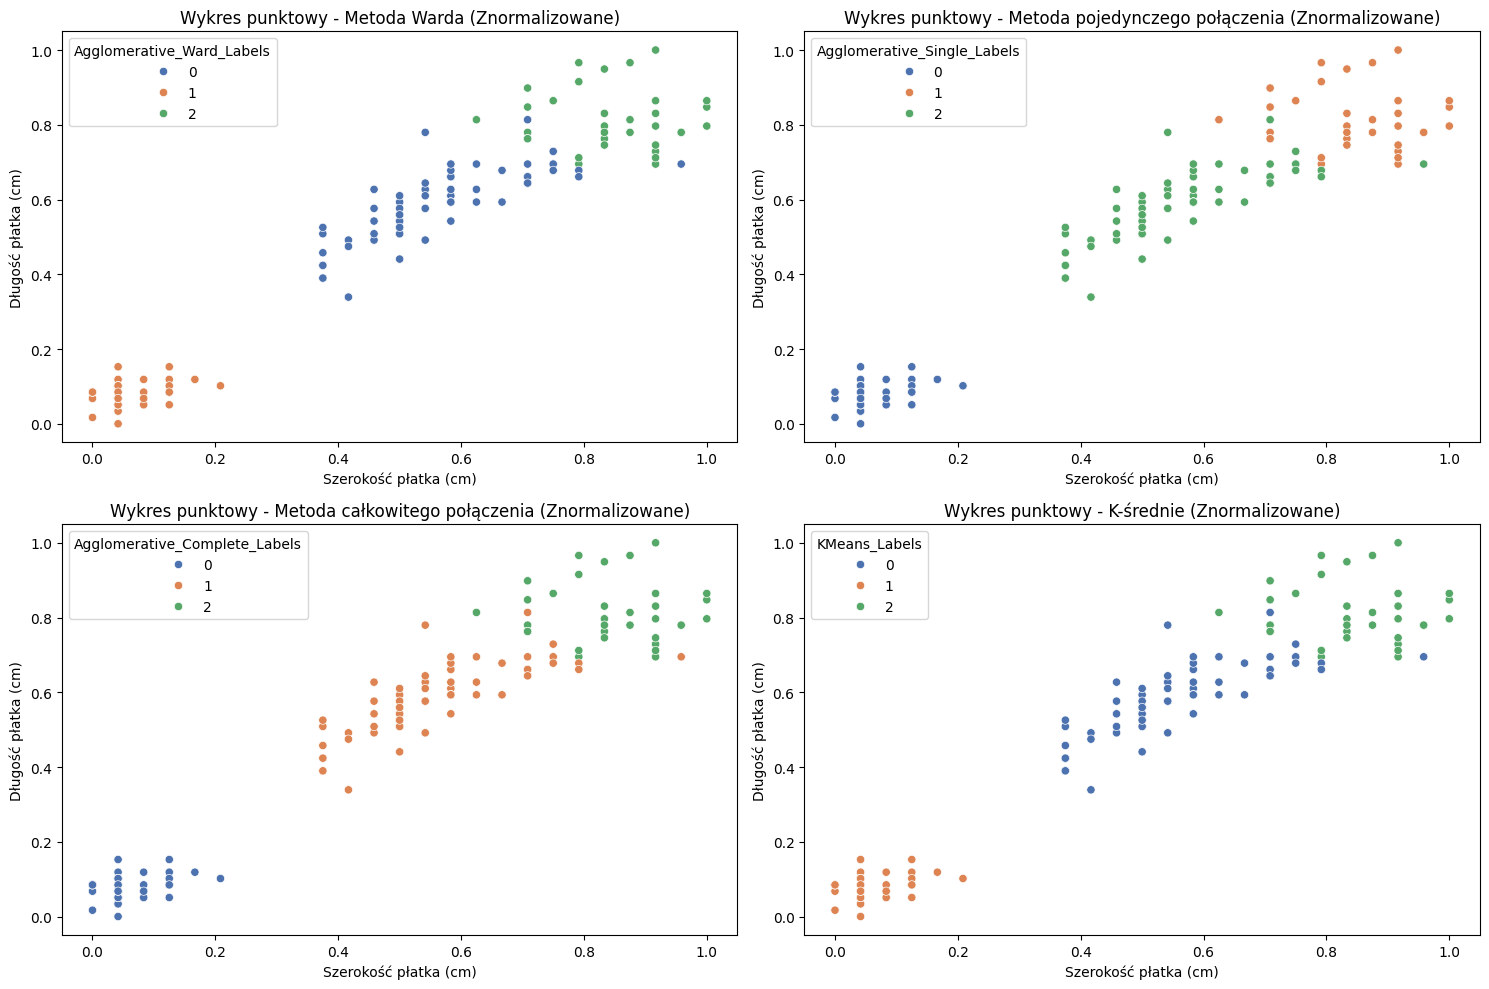

In [23]:
n_clusters = 3

# Klastrowanie aglomeracyjne - metoda Warda
agglom_ward_norm = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df_iris_norm['Agglomerative_Ward_Labels'] = agglom_ward_norm.fit_predict(df_iris_norm)

# Klastrowanie aglomeracyjne - metoda pojedynczego połączenia
agglom_single_norm = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
df_iris_norm['Agglomerative_Single_Labels'] = agglom_single_norm.fit_predict(df_iris_norm)

# Klastrowanie aglomeracyjne - metoda całkowitego połączenia
agglom_complete_norm = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
df_iris_norm['Agglomerative_Complete_Labels'] = agglom_complete_norm.fit_predict(df_iris_norm)

# Klastrowanie k-średnich
kmeans_norm = KMeans(n_clusters=n_clusters, random_state=42)
df_iris_norm['KMeans_Labels'] = kmeans_norm.fit_predict(df_iris_norm)

# Wykresy punktowe dla danych znormalizowanych
plt.figure(figsize=(15, 10))

# Wykres dla metody Warda
plt.subplot(2, 2, 1)
sns.scatterplot(data=df_iris_norm, x='petal_width', y='petal_length', hue='Agglomerative_Ward_Labels', palette='deep')
plt.title('Wykres punktowy - Metoda Warda (Znormalizowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

# Wykres dla metody pojedynczego połączenia
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_iris_norm, x='petal_width', y='petal_length', hue='Agglomerative_Single_Labels', palette='deep')
plt.title('Wykres punktowy - Metoda pojedynczego połączenia (Znormalizowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

# Wykres dla metody całkowitego połączenia
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_iris_norm, x='petal_width', y='petal_length', hue='Agglomerative_Complete_Labels', palette='deep')
plt.title('Wykres punktowy - Metoda całkowitego połączenia (Znormalizowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

# Wykres dla k-średnich
plt.subplot(2, 2, 4)
sns.scatterplot(data=df_iris_norm, x='petal_width', y='petal_length', hue='KMeans_Labels', palette='deep')
plt.title('Wykres punktowy - K-średnie (Znormalizowane)')
plt.xlabel('Szerokość płatka (cm)')
plt.ylabel('Długość płatka (cm)')

plt.tight_layout()
plt.show()
